In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/yapo_listing_raw.csv')
print(df.shape)
df.head()


(14909, 12)


,id,titulo,precio_clp,año,combustible,transmision,kilometraje,vendedor,region,destacado,url,fecha_scraping
0,32079793,BMW 320 IA AÑO 2010,$5.780.000,2010,Bencina,Automática,122690 km,Juan Pablo HZ,region-metropolitana,False,https://www.yapo.cl/autos-usados/bmw-320-ia-an...,2026-03-05
1,32079731,focos neblineros peugeot 308 2012 t7,$35.000,2012,Bencina,Manual,NaN,_15111731 Lucero,region-metropolitana,False,https://www.yapo.cl/autos-usados/focos-nebline...,2026-03-05
2,32079630,2015 Peugeot 208 ALLURE E HDI 1.6,$9.280.000,2015,Diesel,Automática,54997 km,Pedro Pelayo,region-metropolitana,False,https://www.yapo.cl/autos-usados/2015-peugeot-...,2026-03-05
3,31650267,Ford Thunderbird 1963 RESTAURADA,$21.990.000-8%,1963,Bencina,Automática,40000 km,MAO Autos,region-metropolitana,False,https://www.yapo.cl/autos-usados/ford-thunderb...,2026-03-05
4,32019792,Kia Frontier 2.5L 2018 Único Dueño OPORTUNIDAD,$11.490.000-2%,2018,Diesel,Manual,184000 km,MAO Autos,region-metropolitana,False,https://www.yapo.cl/autos-usados/kia-frontier-...,2026-03-05


In [2]:
nulos = df.isnull().sum().sort_values(ascending=False)
print((nulos / len(df) * 100).round(1).astype(str) + '%')


kilometraje       2.1%
precio_clp        1.4%
transmision       0.0%
vendedor          0.0%
titulo            0.0%
año               0.0%
combustible       0.0%
id                0.0%
region            0.0%
destacado         0.0%
url               0.0%
fecha_scraping    0.0%
dtype: str


In [3]:
df['region'].value_counts()


region
region-metropolitana    7019
valparaiso              2850
biobio                  2520
antofagasta             1500
los-lagos               1020
Name: count, dtype: int64

In [4]:
df['año'].value_counts().head(20)


año
2022    1174
2021    1051
2019    1049
2018    1026
2017    1024
2023     912
2014     860
2013     773
2016     763
2015     702
2020     674
2012     645
2011     617
2024     603
2010     426
2025     360
2008     344
2007     277
2009     261
2006     232
Name: count, dtype: int64

In [5]:
df['precio_num'] = (
    df['precio_clp']
    .str.replace(r'[^\d]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
df['precio_num'].describe()


count    1.470000e+04
mean     6.525226e+07
std      5.193435e+08
min      1.000000e+00
25%      6.000000e+06
50%      9.980000e+06
75%      1.860500e+07
max      5.300000e+10
Name: precio_num, dtype: float64

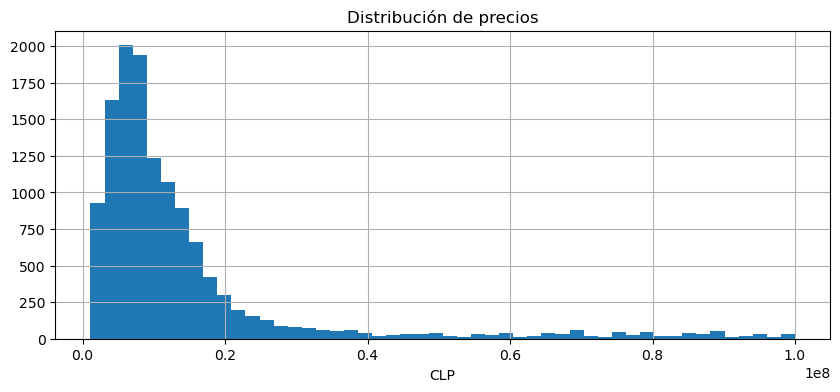

In [6]:
df_precio = df[(df['precio_num'] > 1_000_000) & (df['precio_num'] < 100_000_000)]
df_precio['precio_num'].hist(bins=50, figsize=(10,4))
plt.title('Distribución de precios')
plt.xlabel('CLP')
plt.show()


In [7]:
sin_precio = df['precio_clp'].isna().sum()
consultar = df['precio_clp'].str.contains('Consultar', na=False).sum()
print(f"Sin precio: {sin_precio}")
print(f"'Consultar': {consultar}")
print(f"Con precio numérico: {len(df) - sin_precio - consultar}")


Sin precio: 209
'Consultar': 0
Con precio numérico: 14700


In [12]:
# Rango razonable: $1M a $150M CLP
df_limpio = df[(df['precio_num'] >= 1_000_000) & (df['precio_num'] <= 550_000_000)]
print(f"Anuncios después del filtro: {len(df_limpio)}")


Anuncios después del filtro: 14063


In [24]:
# En un notebook o al final del script de prueba
df_test = pd.read_csv('../data/raw/yapo_detail_raw.csv')
print(df_test.shape)
print(df_test[['id','fecha_publicacion','comuna','marca','modelo','direccion']].to_string())


(10, 10)
         id fecha_publicacion        comuna      marca       modelo                                                 direccion
0  32079793        05/03/2026         Ñuñoa        BMW          320  Presidente Jose Batlle y Ordoñez 3701, Ñuñoa, Santiago -
1  32079731        05/03/2026         Maipú    Peugeot          308                                                       NaN
2  32079630        05/03/2026      La Reina    Peugeot          208                                  AVDA OSSA 315 LA REINA -
3  31650267        05/03/2026    San Miguel       Ford  Thunderbird               Av. José Joaquín Prieto 5650, San Miguel. -
4  32019792        05/03/2026    San Miguel        Kia     Frontier               Av. José Joaquín Prieto 5650, San Miguel. -
5  32079535        05/03/2026    San Miguel        Kia     Frontier               Av. José Joaquín Prieto 5650, San Miguel. -
6  32079548        05/03/2026      Vitacura      Mazda            3                                          

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

df = pd.read_csv('../data/raw/yapo_listing_raw.csv')
url = df['url'].iloc[0]  # toma la primera URL

HEADERS = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}

resp = requests.get(url, headers=HEADERS, timeout=15)
soup = BeautifulSoup(resp.text, 'html.parser')

# Ver TODOS los li, div y span que contengan texto relevante
print("=== LI tags ===")
for tag in soup.find_all('li')[:30]:
    print(repr(tag))

print("\n=== Clases únicas en la página ===")
clases = set()
for tag in soup.find_all(True):
    for c in tag.get('class', []):
        if 'attr' in c.lower() or 'detail' in c.lower() or 'spec' in c.lower() or 'prop' in c.lower():
            clases.add(c)
print(clases)


=== LI tags ===
<li class="d3-breadcrumb__list-element" itemprop="itemListElement" itemscope="" itemtype="http://schema.org/ListItem">
<a href="/" itemprop="item"><span itemprop="name">Inicio</span></a>
<meta content="1" itemprop="position">
</meta></li>
<li class="d3-breadcrumb__list-element" itemprop="itemListElement" itemscope="" itemtype="http://schema.org/ListItem">
<a class="js-breadcrumb-dropdown-open" href="/autos" itemprop="item"><span itemprop="name">Vehículos</span></a>
<meta content="1" itemprop="position"/>
<div class="d3-breadcrumb__dropdown">
<ul class="d3-list d3-breadcrumb__dropdown-content">
<li class="d3-list__item"><a class="d3-list__link js-breadcrumb-dropdown-close" href="/bienes-raices">Inmuebles</a></li><li class="d3-list__item"><a class="d3-list__link js-breadcrumb-dropdown-close" href="/empleos">Empleos y Servicios</a></li><li class="d3-list__item"><a class="d3-list__link js-breadcrumb-dropdown-close" href="/marketplace">Marketplace</a></li> </ul>
</div>
</li>

In [17]:
# Buscar la fecha en la página de detalle
print("=== Clases 'about' y 'info' con texto ===")
for tag in soup.find_all(class_=lambda c: c and ('about__detail' in c or 'info__header' in c or 'toolbar__item' in c)):
    texto = tag.get_text(strip=True)
    if texto:
        print(f"Clase: {tag.get('class')} → '{texto}'")

print("\n=== Buscar texto con fecha directamente ===")
import re
for tag in soup.find_all(True):
    texto = tag.get_text(strip=True)
    if re.search(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}', texto) or 'publicad' in texto.lower() or 'hace' in texto.lower():
        print(f"Tag: {tag.name} | Clase: {tag.get('class')} → '{texto[:80]}'")


=== Clases 'about' y 'info' con texto ===
Clase: ['d3-property-toolbar__item'] → 'Comparte este anuncio'
Clase: ['d3-property-toolbar__item'] → 'Reportar abuso'
Clase: ['d3-property-info__header'] → 'Ñuñoa05/03/2026'
Clase: ['d3-property-info__header-data'] → 'Ñuñoa05/03/2026'
Clase: ['d3-property-about__details'] → 'FinanciamientonoColorGRIS'
Clase: ['d3-property-about__detail-label'] → 'Financiamientono'
Clase: ['d3-property-about__detail'] → 'no'
Clase: ['d3-property-about__detail-label'] → 'ColorGRIS'
Clase: ['d3-property-about__detail'] → 'GRIS'

=== Buscar texto con fecha directamente ===
Tag: html | Clase: None → 'BMW 320 2010 122690 km Bencina Automática en Ñuñoa | BMW 320 IA AÑO 2010Vehículo'
Tag: body | Clase: ['d3', 'd3-vertical--cars', 'cat-500', 'cat-498', 'theme-yapo'] → 'VehículosAutos UsadosAutos NuevosMotosCamiones, Buses y Casa RodanteArriendo de '
Tag: script | Clase: None → '{
  "@context":"http://schema.org",
  "@type":"Car",
  "description": "BMW 320 I'
Tag: div |

In [20]:
df_test = pd.read_csv('../data/raw/yapo_detail_raw.csv')
# Ver el campos_raw de la primera fila con datos
print(df_test['campos_raw'].iloc[0])


{'marca': 'BMW', 'modelo': '320', 'precio': '$5.780.000', 'año': '2010', 'kilómetros': "122'690", 'combustible': 'Bencina', 'financiamientono': 'no', 'colorgris': 'GRIS'}


In [22]:
import requests
from bs4 import BeautifulSoup

df = pd.read_csv('../data/raw/yapo_listing_raw.csv')
url = df['url'].iloc[0]
HEADERS = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}

resp = requests.get(url, headers=HEADERS, timeout=15)
soup = BeautifulSoup(resp.text, 'html.parser')

# Debug directo del bloque que falla
print("=== d3-property-details__detail-label ===")
for label_tag in soup.find_all(class_='d3-property-details__detail-label'):
    print(f"\nHTML completo: {label_tag}")
    label_text = label_tag.find(text=True, recursive=False)
    value_tag  = label_tag.find(class_='d3-property-details__detail')
    print(f"label_text: {repr(label_text)}")
    print(f"value_tag:  {repr(value_tag)}")


=== d3-property-details__detail-label ===

HTML completo: <div class="d3-property-details__detail-label">
    Localización    <p class="d3-property-details__detail">Ñuñoa</p>
</div>
label_text: '\n    Localización    '
value_tag:  <p class="d3-property-details__detail">Ñuñoa</p>

HTML completo: <div class="d3-property-details__detail-label">
    Publicado    <p class="d3-property-details__detail">05/03/2026</p>
</div>
label_text: '\n    Publicado    '
value_tag:  <p class="d3-property-details__detail">05/03/2026</p>

HTML completo: <div class="d3-property-details__detail-label">
    Tamaño del motor    <p class="d3-property-details__detail">2.0</p>
</div>
label_text: '\n    Tamaño del motor    '
value_tag:  <p class="d3-property-details__detail">2.0</p>

HTML completo: <div class="d3-property-details__detail-label">
    Transmisión    <p class="d3-property-details__detail">Automática</p>
</div>
label_text: '\n    Transmisión    '
value_tag:  <p class="d3-property-details__detail">Autom

/tmp/ipykernel_42832/1183547347.py:15: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  label_text = label_tag.find(text=True, recursive=False)
